In [7]:
import sys
import os

PROJECT_ROOT = os.path.dirname(os.getcwd())
sys.path.append(os.path.join(PROJECT_ROOT, "src"))

In [8]:
from dataset import make_concentric_rings
from model import ToyResNet2D
import matplotlib.pyplot as plt
import numpy as np
import torch

In [9]:
X, y = make_concentric_rings()

In [10]:
@torch.no_grad()
def get_residuals(X, config_path):
    model_info = torch.load(config_path, map_location="cpu")
    model = ToyResNet2D(**model_info["config"]["model"])
    ln = model_info["model_state_dict"]
    model.load_state_dict(ln)
    model.eval()
    _, _, rs = model(torch.from_numpy(X), return_traj=True)
    return rs

In [11]:
def plot_block_field(X, rs, layer=0, n=25, seed=0):
    """
    X: (N,2) points
    rs: list (or tensor) where rs[layer] is (N,2) residual vectors
    """
    
    r = rs[layer]
    N = X.shape[0]
    k = n * n
    if k > N:
        raise ValueError(f"Need at least {k} points, but got {N}.")

    rng = np.random.default_rng(seed)
    idx = rng.choice(N, k, replace=False)

    Xs = X[idx]   
    rs_s = r[idx]   

    # reshape coordinates and vectors
    Xg = Xs[:, 0].reshape(n, n)
    Yg = Xs[:, 1].reshape(n, n)
    U  = rs_s[:, 0].reshape(n, n)
    V  = rs_s[:, 1].reshape(n, n)

    title = f"Residual field block {layer} (sampled {k}/{N}) with layernorm" if with_ln else f"Residual field block {layer} (sampled {k}/{N}) without layernorm"
    plt.figure(figsize=(6,6))
    plt.quiver(Xg, Yg, U, V, angles="xy", scale_units="xy", scale=40)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(title)
    plt.show()

In [12]:
def plot_sample_trajectory(X, rs, sample_idx=0):

    title = "Sample trajectory through layers with layernorm" if with_ln else "Sample trajectory through layers without layernorm" 
    num_layers = len(rs)
    h = torch.from_numpy(X[sample_idx].copy())
    trajectory = [h]

    for l in range(num_layers):
        r = rs[l][sample_idx]
        h = h + r
        trajectory.append(h)

    trajectory = np.array(trajectory)

    plt.figure(figsize=(6,6))
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)

    plt.plot(trajectory[:,0], trajectory[:,1], '-o')

    for i in range(len(trajectory)-1):
        dx = trajectory[i+1,0] - trajectory[i,0]
        dy = trajectory[i+1,1] - trajectory[i,1]

        plt.arrow(
            trajectory[i,0],
            trajectory[i,1],
            dx,
            dy,
            head_width=0.03,
            length_includes_head=True
        )

    plt.scatter(trajectory[0,0], trajectory[0,1], color='red', label='start', zorder=10)

    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.legend()
    plt.show()

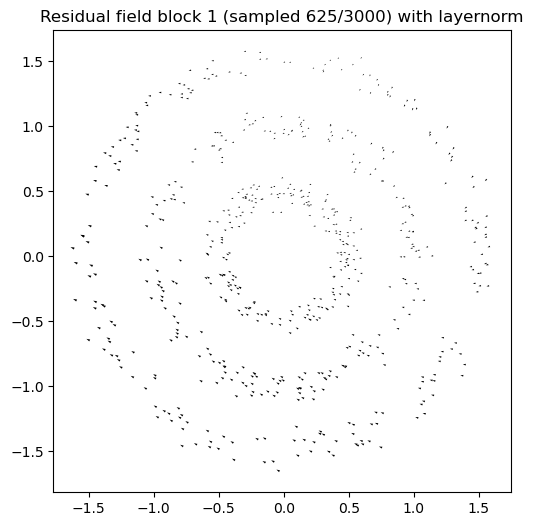

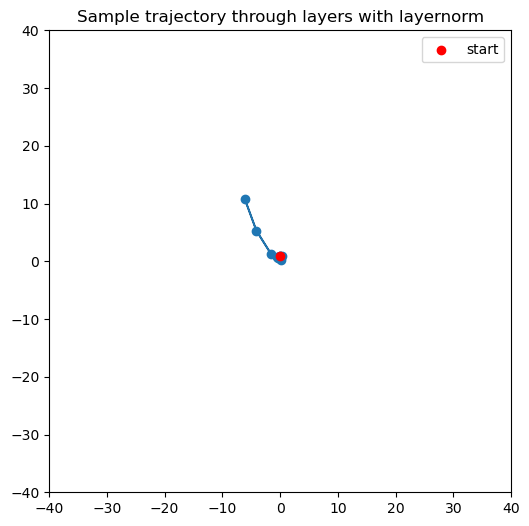

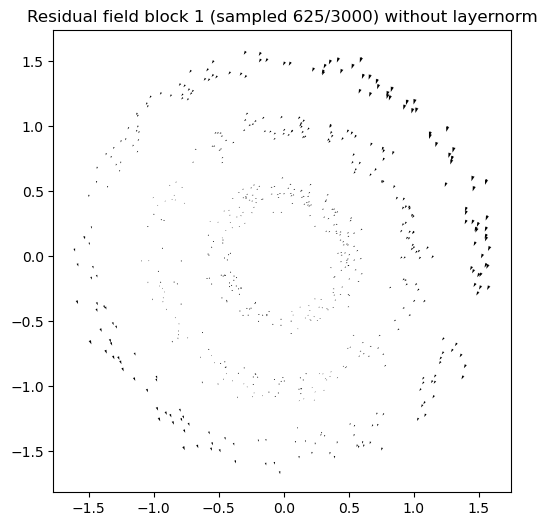

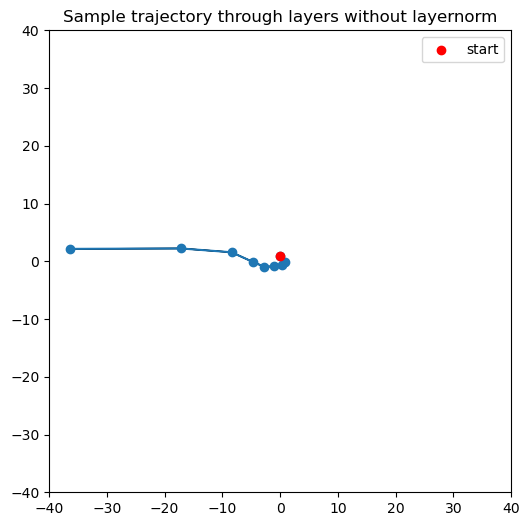

In [15]:
for with_ln in [True, False]:
    config_path = os.path.join(PROJECT_ROOT, "checkpoints", "ln.pt") if with_ln else os.path.join(PROJECT_ROOT, "checkpoints", "no_ln.pt")
    rs = get_residuals(X, config_path)
    plot_block_field(X, rs, layer=1)
    plot_sample_trajectory(X, rs)